Conditions
* 10: 2 hour GC incubation, 6uL M.CviPI in 200 uL Hia5 buffer
* 11: 15 min. GC incubation, 6uL M.CviPI in 200 uL Hia5 buffer
* 12: nanoNOMe incubation, 15 min. GC incubation, 50uL M.CviPI in 500 uL nanoNOMe buffer, lots of nuclei
* 13: no-accessibility control
* 14: nanoNOMe incubation, 15 min. GC incubation, 50uL M.CviPI in 500 uL nanoNOMe buffer, 500k nuclei

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import config, plotting
from dimelo import parse_bam, plot_enrichment_profile

In [4]:
reference_file = config.raw_data_dir / "chm13v2.0.fa"
ctcf_bed_file = config.processed_data_dir / "gm12878_ctcf_chip_intersect_motif.top3k.bed"
bam_dir = config.processed_data_dir / "20240831_GpC_CpG_crosstalk_demuxed"
barcodes = [10, 11, 12, 13]

window_size = 1500
motifs = ["A,0", "GCH,1", "WCG,1"]
mod_prob_thresh = 0.95
smoothing = 25
n_cores = 10

y_lim = (-0.01, 0.55)

In [ ]:
for barcode in barcodes:
    bam_file = bam_dir / f"barcode{barcode}.bam"
    # TODO: This should be renamed so that there is no risk of overlapping with demuxed files from another dataset; maybe make a subdirectory?
    output_id = f"{bam_file.stem}.{ctcf_bed_file.stem}"
    parse_bam.pileup(
        input_file=bam_file,
        output_name=f"pileup.{output_id}",
        ref_genome=reference_file,
        output_directory=config.processed_data_dir,
        regions=ctcf_bed_file,
        motifs=motifs,
        thresh=mod_prob_thresh,
        window_size=window_size,
        cores=n_cores,
        override_checks=True
    )

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

...

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

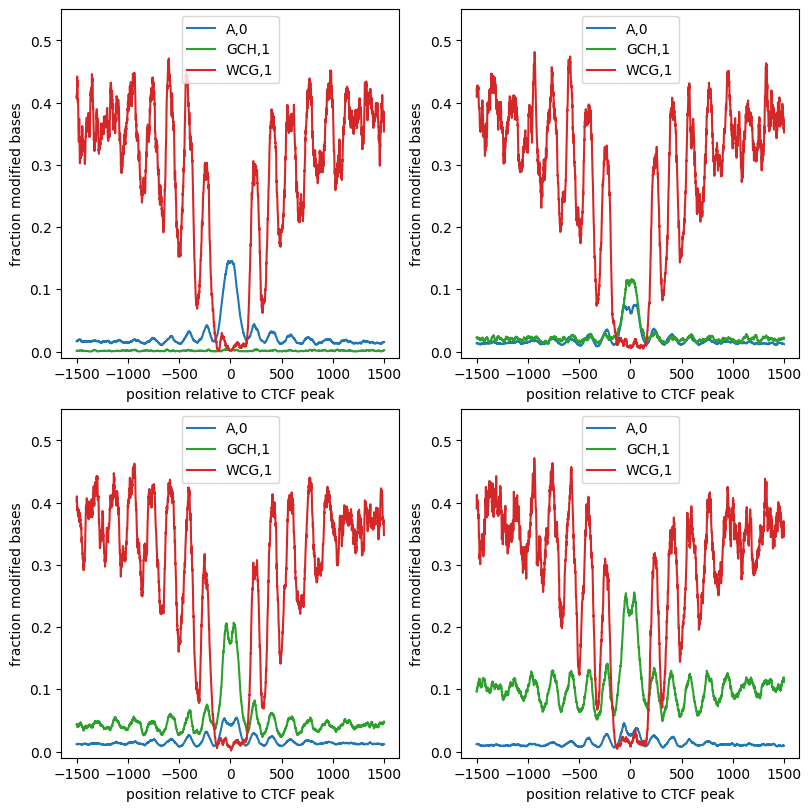

In [5]:
_, axs = plt.subplots(2, 2, figsize=(8, 8), layout="constrained")
for barcode, ax in zip([13, 11, 10, 12], np.ravel(axs)):
    bam_file = bam_dir / f"barcode{barcode}.bam"
    # TODO: This should be renamed so that there is no risk of overlapping with demuxed files from another dataset; maybe make a subdirectory?
    output_id = f"{bam_file.stem}.{ctcf_bed_file.stem}"
    plot_enrichment_profile.by_modification(
        config.processed_data_dir / f"pileup.{output_id}" / "pileup.sorted.bed.gz",
        regions=ctcf_bed_file,
        motifs=motifs,
        window_size=window_size,
        smooth_window=smoothing,
        palette=plotting.default_palette_map,
        ax=ax
    )
    ax.set_xlabel("position relative to CTCF peak")
    ax.set_ylim(y_lim)
    ax.legend(title="")

plt.savefig(config.figure_dir / "crosstalk.plot_enrichment_profile.svg")
plt.show()
plt.close()